# uv-CS: pure quantum fluids and combining rules for helium / hydrogen

1. Pure-fluid VLE of helium and (normal) hydrogen: uv-CS with the parameters of Ziegler (2026) and SAFT-VRQ Mie (FH1, Aasen et al. 2019) compared to NIST data.
2. Binary VLE of helium (1) / hydrogen (2) with uv-CS using different combining rules for the cross repulsive exponent $\nu_{ij}$ and the cross energy $\varepsilon_{ij}$, compared to SAFT-VRQ Mie (Aasen et al. 2020), GEMC simulations and experimental data from the Dortmund Data Bank (DDB).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import si_units as si
import feos
from feos import EquationOfState, Parameters, PhaseDiagram, PhaseEquilibrium, State
from IPython.display import Markdown

## uv-CS model: effective Mie parameters

Quantum effects enter through temperature-dependent effective Mie parameters of a classical Mie fluid (attractive exponent fixed at 6). With the reduced de Broglie-type parameter

$$
D^* = \frac{\hbar^2}{12\, m\, k_\mathrm{B} T\, \sigma^2}
$$

the effective parameters are

$$
\frac{\nu^{\text{eff}}}{\nu} =
\frac{1 + \xi_0(\nu)\, C^\nu_0(\nu)\,D^* + \xi_1(\nu)\, C^\nu_1(\nu)\,D^{*2} + \xi_2(\nu)\, C^\nu_2(\nu)\,D^{*3}}
     {1 + \xi_3(\nu)\, C^\nu_3(\nu)\,D^* + \xi_4(\nu)\, C^\nu_4(\nu)\,D^{*2}}
$$

$$
\frac{\sigma^{\text{eff}}}{\sigma} =
\frac{1 + \xi_0(\sigma)\, C^\sigma_0(\nu)\,D^* + \xi_1(\sigma)\, C^\sigma_1(\nu)\,D^{*2} + \xi_3(\sigma)\,D^{*3}}
     {1 + \xi_2(\sigma)\, C^\sigma_2(\nu)\,D^* + \xi_4(\sigma)\,D^{*2}}
$$

$$
\frac{\varepsilon^{\text{eff}}}{\varepsilon} =
\frac{1 + \xi_0(\varepsilon)\, C^\varepsilon_0(\nu)\,D^* + \xi_1(\varepsilon)\, C^\varepsilon_1(\nu)\,D^{*2} + \xi_3(\varepsilon)\,D^{*3}}
     {1 + \xi_2(\varepsilon)\, C^\varepsilon_2(\nu)\,D^* + \xi_4(\varepsilon)\,D^{*2}}
$$

where the $C_k(\nu)$ are quadratic polynomials in the classical repulsive exponent $\nu$, fitted to the first-order Feynman–Hibbs (FH1) potential. With $\xi_0 = \xi_1 = \xi_2 = 1$ and $\xi_3(\sigma) = \xi_4(\sigma) = \xi_3(\varepsilon) = \xi_4(\varepsilon) = 0$ (and all $\xi(\nu) = 1$), the FH1 corresponding-states model is recovered. In feos, the coefficients are passed as `c_rep` $= [\xi_0(\nu), \dots, \xi_4(\nu)]$, `c_sigma` $= [\xi_0(\sigma), \dots, \xi_4(\sigma)]$ and `c_epsilon_k` $= [\xi_0(\varepsilon), \dots, \xi_4(\varepsilon)]$.

### Parameters (Ziegler 2026)

Classical Mie parameters and correction parameters fitted in two stages. For hydrogen, the parameters of normal hydrogen are used (consistent with the NIST data).

In [2]:
MW = dict(helium=4.002602, hydrogen=2.01588)

# uv-CS parameters, Ziegler (2026)
ZIEGLER2026 = dict(
    helium=dict(
        sigma=2.685576, epsilon_k=8.538732, rep=10.788977, att=6.0,
        c_rep=[1.0, 1.151765, -6.107946, 1.0, 1.0],
        c_sigma=[1.0, 2.730451, 1.0, -257.843813, 0.0],
        c_epsilon_k=[1.0, 1.250274, 1.0, -1428.749516, 2051.147273],
    ),
    hydrogen=dict(
        sigma=3.025765, epsilon_k=31.690343, rep=10.689166, att=6.0,
        c_rep=[1.0, 1.347585, 1.0, 1.0, 1.0],
        c_sigma=[1.0, -2.789573, 1.0, 0.0, 0.0],
        c_epsilon_k=[1.0, -0.620551, 1.0, 0.0, 0.0],
    ),
)

# SAFT-VRQ Mie (FH1), Aasen et al. (2019)
AASEN2019 = dict(
    helium=dict(m=1.0, sigma=2.7443, epsilon_k=5.4195, lr=9.0, la=6.0, fh=1),
    hydrogen=dict(m=1.0, sigma=3.0243, epsilon_k=26.706, lr=9.0, la=6.0, fh=1),
)


def parameter_table(params):
    """Markdown table of the uv-CS parameters (LaTeX labels are rendered in Markdown, not in DataFrame HTML)."""
    names = list(params)
    rows = [
        ("$\\sigma$ / Å", "sigma", None),
        ("$\\varepsilon/k_\\mathrm{B}$ / K", "epsilon_k", None),
        ("$\\nu$", "rep", None),
    ]
    for key, sym in [("c_rep", "\\nu"), ("c_sigma", "\\sigma"), ("c_epsilon_k", "\\varepsilon")]:
        rows += [(f"$\\xi_{k}({sym})$", key, k) for k in range(5)]
    lines = ["| parameter | " + " | ".join(names) + " |", "|---|" + "---:|" * len(names)]
    for label, key, k in rows:
        values = [params[n][key] if k is None else params[n][key][k] for n in names]
        lines.append(f"| {label} | " + " | ".join(f"{v:.10g}" for v in values) + " |")
    return Markdown("\n".join(lines))


parameter_table(ZIEGLER2026)

| parameter | helium | hydrogen |
|---|---:|---:|
| $\sigma$ / Å | 2.685576 | 3.025765 |
| $\varepsilon/k_\mathrm{B}$ / K | 8.538732 | 31.690343 |
| $\nu$ | 10.788977 | 10.689166 |
| $\xi_0(\nu)$ | 1 | 1 |
| $\xi_1(\nu)$ | 1.151765 | 1.347585 |
| $\xi_2(\nu)$ | -6.107946 | 1 |
| $\xi_3(\nu)$ | 1 | 1 |
| $\xi_4(\nu)$ | 1 | 1 |
| $\xi_0(\sigma)$ | 1 | 1 |
| $\xi_1(\sigma)$ | 2.730451 | -2.789573 |
| $\xi_2(\sigma)$ | 1 | 1 |
| $\xi_3(\sigma)$ | -257.843813 | 0 |
| $\xi_4(\sigma)$ | 0 | 0 |
| $\xi_0(\varepsilon)$ | 1 | 1 |
| $\xi_1(\varepsilon)$ | 1.250274 | -0.620551 |
| $\xi_2(\varepsilon)$ | 1 | 1 |
| $\xi_3(\varepsilon)$ | -1428.749516 | 0 |
| $\xi_4(\varepsilon)$ | 2051.147273 | 0 |

In [3]:
def uvcs_record(name):
    return feos.PureRecord(feos.Identifier(name=name), MW[name], **ZIEGLER2026[name])


def vrq_record(name):
    return feos.PureRecord(feos.Identifier(name=name), MW[name], **AASEN2019[name])


pure_models = {
    name: {
        "uv-CS (Ziegler 2026)": EquationOfState.uvcstheory(Parameters.new_pure(uvcs_record(name))),
        "SAFT-VRQ Mie (Aasen 2019)": EquationOfState.saftvrqmie(Parameters.new_pure(vrq_record(name))),
    }
    for name in ["helium", "hydrogen"]
}
pure_styles = {
    "uv-CS (Ziegler 2026)": dict(color="C0", ls="-"),
    "SAFT-VRQ Mie (Aasen 2019)": dict(color="k", ls="--"),
}

## Pure fluids: comparison to NIST

In [4]:
def read_nist(fname):
    d = pd.read_csv(fname, sep="\t")
    # vapor rows have no surface tension -> the phase label is shifted one column to the left
    d["Phase"] = d["Phase"].fillna(d["Surf. Tension (N/m)"])
    cols = {"Temperature (K)": "T", "Pressure (MPa)": "p", "Density (kg/m3)": "rho"}
    d = d.rename(columns=cols)[["T", "p", "rho", "Phase"]]
    liq = d[d["Phase"] == "liquid"].set_index("T")
    vap = d[d["Phase"] == "vapor"].set_index("T")
    return pd.DataFrame({"p": 10 * liq["p"], "rho_l": liq["rho"], "rho_v": vap["rho"]}).reset_index()  # p in bar


nist = {
    "helium": read_nist("data/NIST/Helium_sat_NIST.txt"),
    "hydrogen": read_nist("data/NIST/Hydrogen_sat_NIST.txt"),
}
T_MIN = dict(helium=2.7, hydrogen=14.0)  # SAFT-VRQ Mie does not converge for helium below ~2.7 K

for name, models_i in pure_models.items():
    for label, eos in models_i.items():
        cp = State.critical_point(eos)
        print(f"{name:9s} {label:26s} T_c = {cp.temperature / si.KELVIN:7.3f} K, p_c = {cp.pressure() / si.BAR:6.3f} bar")
    print(f"{name:9s} {'NIST':26s} T_c = {nist[name]['T'].max():7.3f} K (last tabulated point)")

helium    uv-CS (Ziegler 2026)       T_c =   5.206 K, p_c =  2.283 bar
helium    SAFT-VRQ Mie (Aasen 2019)  T_c =   5.239 K, p_c =  2.292 bar
helium    NIST                       T_c =   5.177 K (last tabulated point)
hydrogen  uv-CS (Ziegler 2026)       T_c =  33.182 K, p_c = 13.055 bar
hydrogen  SAFT-VRQ Mie (Aasen 2019)  T_c =  33.304 K, p_c = 13.630 bar
hydrogen  NIST                       T_c =  32.957 K (last tabulated point)


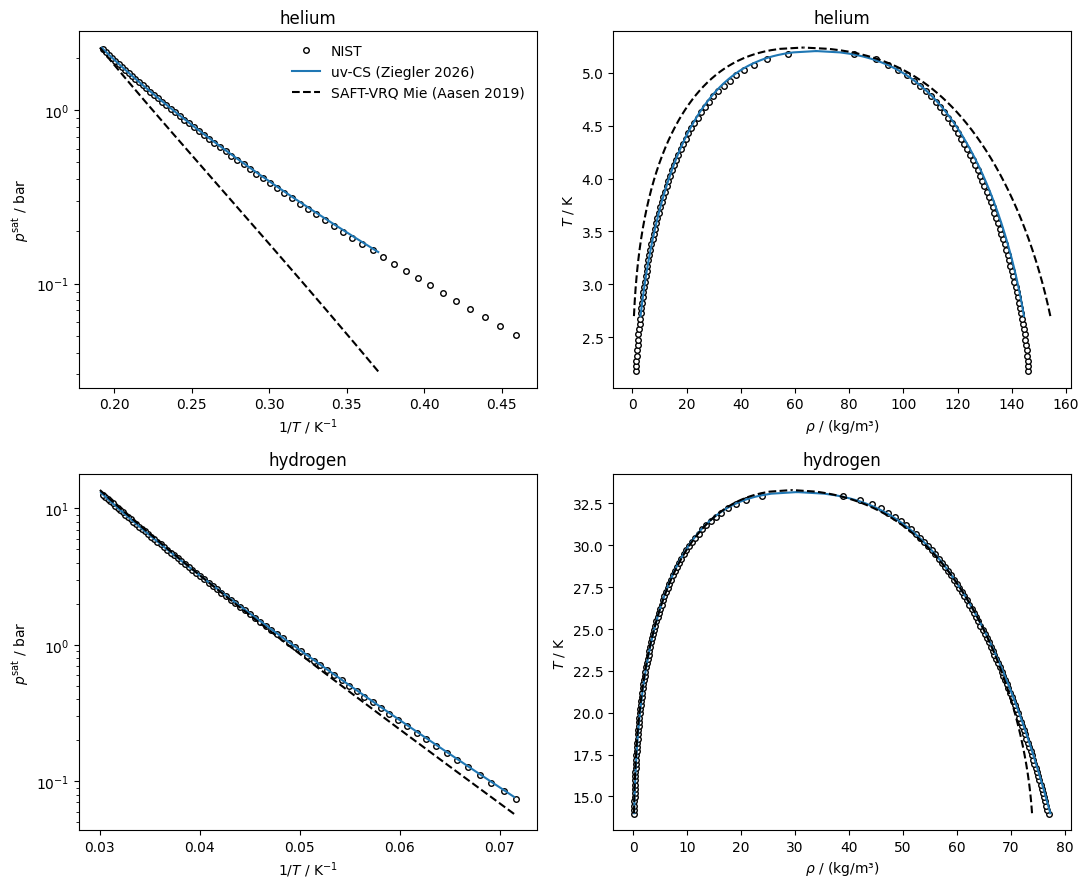

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(11, 9))
for (ax_p, ax_rho), name in zip(axes, ["helium", "hydrogen"]):
    n = nist[name]
    ax_p.plot(1 / n["T"], n["p"], "o", mfc="w", mec="k", ms=4, label="NIST")
    ax_rho.plot(n["rho_l"], n["T"], "o", mfc="w", mec="k", ms=4, label="NIST")
    ax_rho.plot(n["rho_v"], n["T"], "o", mfc="w", mec="k", ms=4)
    for label, eos in pure_models[name].items():
        dia = PhaseDiagram.pure(eos, T_MIN[name] * si.KELVIN, 200)
        T = dia.vapor.temperature / si.KELVIN
        ax_p.plot(1 / T, dia.vapor.pressure / si.BAR, label=label, **pure_styles[label])
        for phase in (dia.liquid, dia.vapor):
            ax_rho.plot(phase.mass_density / (si.KILOGRAM / si.METER**3), T, **pure_styles[label])
    ax_p.set_yscale("log")
    ax_p.set_xlabel(r"$1/T$ / K$^{-1}$")
    ax_p.set_ylabel(r"$p^\mathrm{sat}$ / bar")
    ax_rho.set_xlabel(r"$\rho$ / (kg/m³)")
    ax_rho.set_ylabel(r"$T$ / K")
    ax_p.set_title(name)
    ax_rho.set_title(name)
axes[0, 0].legend(frameon=False)
fig.tight_layout()

Mean absolute relative deviations (in %) from NIST for vapor pressure and saturated liquid / vapor densities, evaluated at the NIST temperatures between $T_\mathrm{min}$ (2.7 K for helium, where SAFT-VRQ Mie stops converging; 14 K for hydrogen) and $0.95\,T_c$.

In [6]:
rows = []
for name, models_i in pure_models.items():
    n = nist[name]
    n = n[(n["T"] >= T_MIN[name]) & (n["T"] < 0.95 * n["T"].max())]
    for label, eos in models_i.items():
        dev = []
        for T, p, rho_l, rho_v in n[["T", "p", "rho_l", "rho_v"]].itertuples(index=False):
            vle = PhaseEquilibrium.pure(eos, T * si.KELVIN)
            dev.append((
                vle.vapor.pressure() / si.BAR / p - 1,
                vle.liquid.mass_density() / (si.KILOGRAM / si.METER**3) / rho_l - 1,
                vle.vapor.mass_density() / (si.KILOGRAM / si.METER**3) / rho_v - 1,
            ))
        dev = 100 * np.abs(np.array(dev)).mean(axis=0)
        rows.append(dict(fluid=name, model=label, p_sat=dev[0], rho_liquid=dev[1], rho_vapor=dev[2]))
pd.DataFrame(rows).set_index(["fluid", "model"]).round(2)

p_sat  rho_liquid  rho_vapor
fluid    model                                                  
helium   uv-CS (Ziegler 2026)        1.24        0.79       1.23
         SAFT-VRQ Mie (Aasen 2019)  40.71        6.00      47.47
hydrogen uv-CS (Ziegler 2026)        0.95        0.34       0.88
         SAFT-VRQ Mie (Aasen 2019)   5.97        0.96       5.90

## Mixture helium / hydrogen

Combining rules for the cross parameters, applied to the **effective** (temperature-dependent) pure-component parameters:

| model | $\nu_{ij}$ | $\varepsilon_{ij}$ |
|---|---|---|
| uv-CS (original) | $\sqrt{\nu_i \nu_j}$ | $\sqrt{\varepsilon_i \varepsilon_j}\,(1-k_{ij})$ |
| uv-CS (SAFT-VR ν) | $3 + \sqrt{(\nu_i-3)(\nu_j-3)}$ | $\sqrt{\varepsilon_i \varepsilon_j}\,(1-k_{ij})$ |
| uv-CS (SAFT-VR ν, ε) | $3 + \sqrt{(\nu_i-3)(\nu_j-3)}$ | $\frac{\sqrt{\sigma_i^3\sigma_j^3}}{\left(\frac{\sigma_i+\sigma_j}{2}\right)^3}\sqrt{\varepsilon_i \varepsilon_j}\,(1-k_{ij})$ |

$\sigma_{ij} = \frac{\sigma_i + \sigma_j}{2}(1 - l_{ij})$ in all cases; here $k_{ij} = l_{ij} = 0$ for uv-CS. SAFT-VRQ Mie (Aasen et al. 2020) serves as reference, with fitted binary parameters ($k_{ij}=0.08$, $l_{ij}=-0.05$) and without ($k_{ij}=l_{ij}=0$).

In [7]:
uv_params = Parameters.new_binary([uvcs_record("helium"), uvcs_record("hydrogen")])
vrq_params = Parameters.new_binary([vrq_record("helium"), vrq_record("hydrogen")])
vrq_params_kl = Parameters.new_binary([vrq_record("helium"), vrq_record("hydrogen")], k_ij=0.08, l_ij=-0.05)

models = {
    "uv-CS (original)": EquationOfState.uvcstheory(uv_params),
    "uv-CS (SAFT-VR ν)": EquationOfState.uvcstheory(uv_params, rep_combining_rule="saftvrmie"),
    "uv-CS (SAFT-VR ν, ε)": EquationOfState.uvcstheory(
        uv_params, rep_combining_rule="saftvrmie", epsilon_combining_rule="saftvrmie"
    ),
    "SAFT-VRQ Mie (k=l=0)": EquationOfState.saftvrqmie(vrq_params),
    "SAFT-VRQ Mie (k=0.08, l=-0.05)": EquationOfState.saftvrqmie(vrq_params_kl),
}
styles = {
    "uv-CS (original)": dict(color="C0", ls="-"),
    "uv-CS (SAFT-VR ν)": dict(color="C1", ls="--"),
    "uv-CS (SAFT-VR ν, ε)": dict(color="C2", ls="-."),
    "SAFT-VRQ Mie (k=l=0)": dict(color="0.5", ls=":"),
    "SAFT-VRQ Mie (k=0.08, l=-0.05)": dict(color="k", ls="-"),
}

### Reference data

GEMC simulations:

In [8]:
data = pd.read_csv("../saftvrcs/data/helium_hydrogen_gemc_vle.csv", sep=r"\s+")
data.columns = ["T", "p", "y_he", "x_he", "rho_v", "rho_l"]
temperatures = sorted(data["T"].unique())
data.head()

,T,p,y_he,x_he,rho_v,rho_l
0,20.4,30.0,0.9012,0.0353,16.344,35.910
1,20.4,50.0,0.9045,0.0485,23.660,36.739
2,20.4,70.0,0.9059,0.0559,28.778,37.533
3,20.4,75.0,0.9071,0.0572,29.839,37.717
4,20.4,80.0,0.9100,0.0579,30.812,37.910


Experimental data (DDB export 2023-07, ⁴He only, extracted to `data/helium_hydrogen_ddb_vle.csv`) below the critical temperature of hydrogen. Px(T) and Py(T) data sets contain only one of the two compositions. Streett (1973) measured up to several kbar; DDB flags many of these points as "rather gas-gas or fluid-fluid than vapor-liquid" (the two-phase region closes back towards pure H₂ at high pressure).

In [9]:
exp = pd.read_csv("data/helium_hydrogen_ddb_vle.csv").rename(
    columns={"temperature_K": "T", "pressure_bar": "p"}
)
exp = exp[exp["T"] < 33.0]
references = sorted(exp["reference"].unique())
markers = dict(zip(references, "sD^v<>ph"))
exp.groupby("reference").agg(
    n=("p", "size"), T_min=("T", "min"), T_max=("T", "max"), p_max=("p", "max")
)

,n,T_min,T_max,p_max
reference,,,,
Hiza 1981,49,20.00,28.00,20.62301
Pashkov 1981,137,14.70,30.01,154.11533
Smith 1952,131,17.40,21.80,58.74335
Sneed 1968,76,15.50,29.80,103.55930
Sonntag 1964,60,20.40,31.50,34.54261
Streett 1964,95,15.50,32.50,34.47380
Streett 1973,106,26.00,31.00,757.99994
Yaminishi 1992,13,17.92,19.11,1.60000


### Phase envelopes

Helium is supercritical at all temperatures, so the isotherms are traced by bubble-point continuation in $x_\mathrm{He}$, starting from (almost) pure hydrogen. Pressure and vapor composition are linearly extrapolated from the last two points as initial guesses. Whenever a bubble point fails, jumps to a different solution branch (pressure decreasing or more than 10 % off the extrapolation), or has crossed the mixture critical point ($y_\mathrm{He} \le x_\mathrm{He}$), the step size is halved — so every curve ends at the mixture critical point (or where the solver stops converging at high pressure).

In [10]:
def bubble_curve(eos, T, dx0=0.01, dx_min=1e-5, x_max=0.95):
    rows = []
    x, dx = 1e-3, 1e-3
    while x < x_max and dx >= dx_min:
        p_init = y_init = None
        if len(rows) >= 2:  # linear extrapolation of p and y in x
            (x1, y1, p1), (x2, y2, p2) = rows[-2], rows[-1]
            s = (x - x2) / (x2 - x1)
            p_init = (p2 + s * (p2 - p1)) * si.BAR
            yi = min(max(y2 + s * (y2 - y1), 1e-8), 1 - 1e-8)
            y_init = np.array([yi, 1 - yi])
        elif rows:
            p_init = rows[-1][2] * si.BAR
        try:
            vle = PhaseEquilibrium.bubble_point(
                eos, T * si.KELVIN, np.array([x, 1 - x]), tp_init=p_init, vapor_molefracs=y_init
            )
            y = vle.vapor.molefracs[0]
            p = vle.vapor.pressure() / si.BAR
            if y - x < 1e-4 * x:  # trivial solution or past the critical point
                raise RuntimeError
            # jump to another solution branch: bubble pressure must increase smoothly
            if rows and p < rows[-1][2]:
                raise RuntimeError
            if len(rows) >= 2 and abs(p * si.BAR / p_init - 1) > 0.1:
                raise RuntimeError
        except KeyboardInterrupt:
            raise
        except BaseException:  # also catches Rust panics (PanicException)
            if not rows:
                break
            x = rows[-1][0] + dx / 2
            dx /= 2
            continue
        rows.append((x, y, p))
        dx = min(2 * dx, dx0)  # small steps at high dilution, where y changes quickly
        x += dx
    return pd.DataFrame(rows, columns=["x_he", "y_he", "p_bar"])


curves = {(name, T): bubble_curve(eos, T) for name, eos in models.items() for T in temperatures}

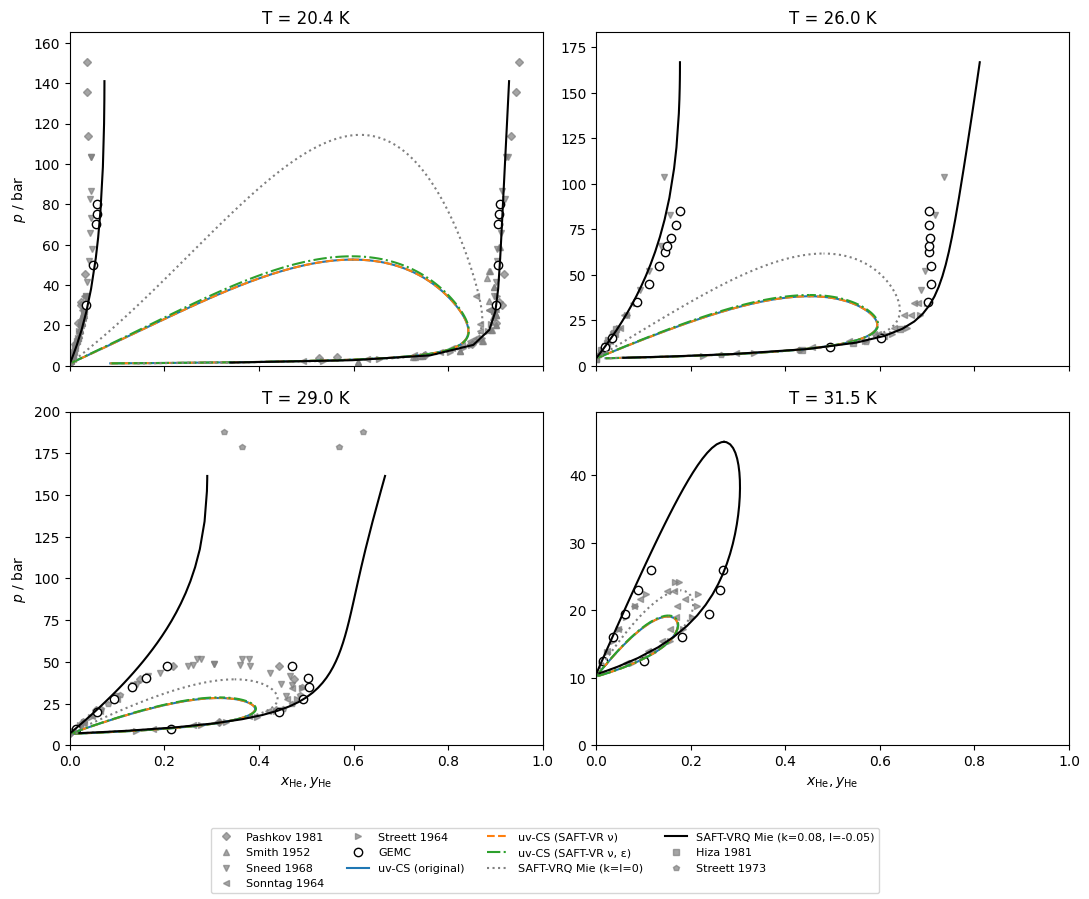

In [11]:
P_MAX = 200.0  # bar, upper limit of the plots


def plot_isotherm(ax, T, curves, gemc=None):
    e = exp[(exp["T"] - T).abs() < 0.06]
    for ref, g in e.groupby("reference"):
        kw = dict(ls="", marker=markers[ref], ms=4, color="C7", alpha=0.7)
        ax.plot(g["x_he"], g["p"], label=ref, **kw)
        ax.plot(g["y_he"], g["p"], **kw)
    if gemc is not None:
        ax.plot(gemc["x_he"], gemc["p"], "o", mfc="w", mec="k", label="GEMC")
        ax.plot(gemc["y_he"], gemc["p"], "o", mfc="w", mec="k")
    for name in models:
        df = curves[name, T]
        if len(df):
            ax.plot(df["x_he"], df["p_bar"], label=name, **styles[name])
            ax.plot(df["y_he"], df["p_bar"], **styles[name])
    p_top = max([e["p"].max() if len(e) else 0] + [gemc["p"].max() if gemc is not None else 0]
                + [curves[n, T]["p_bar"].max() for n in models if len(curves[n, T])])
    ax.set_title(f"T = {T} K")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, min(1.1 * p_top, P_MAX))


def plot_isotherms(temps, curves, gemc=None):
    fig, axes = plt.subplots(2, 2, figsize=(11, 9), sharex=True)
    for ax, T in zip(axes.flat, temps):
        plot_isotherm(ax, T, curves, None if gemc is None else gemc[gemc["T"] == T])
    for ax in axes[1]:
        ax.set_xlabel(r"$x_\mathrm{He}, y_\mathrm{He}$")
    for ax in axes[:, 0]:
        ax.set_ylabel(r"$p$ / bar")
    handles = {}
    for ax in axes.flat:
        for h, l in zip(*ax.get_legend_handles_labels()):
            handles.setdefault(l, h)
    fig.legend(handles.values(), handles.keys(), loc="lower center", ncol=4, fontsize=8)
    fig.tight_layout(rect=(0, 0.1, 1, 1))
    return fig


plot_isotherms(temperatures, curves, data);

#### Additional isotherms (experimental data only)

Pressures above 200 bar (Streett, 1973) are not shown.

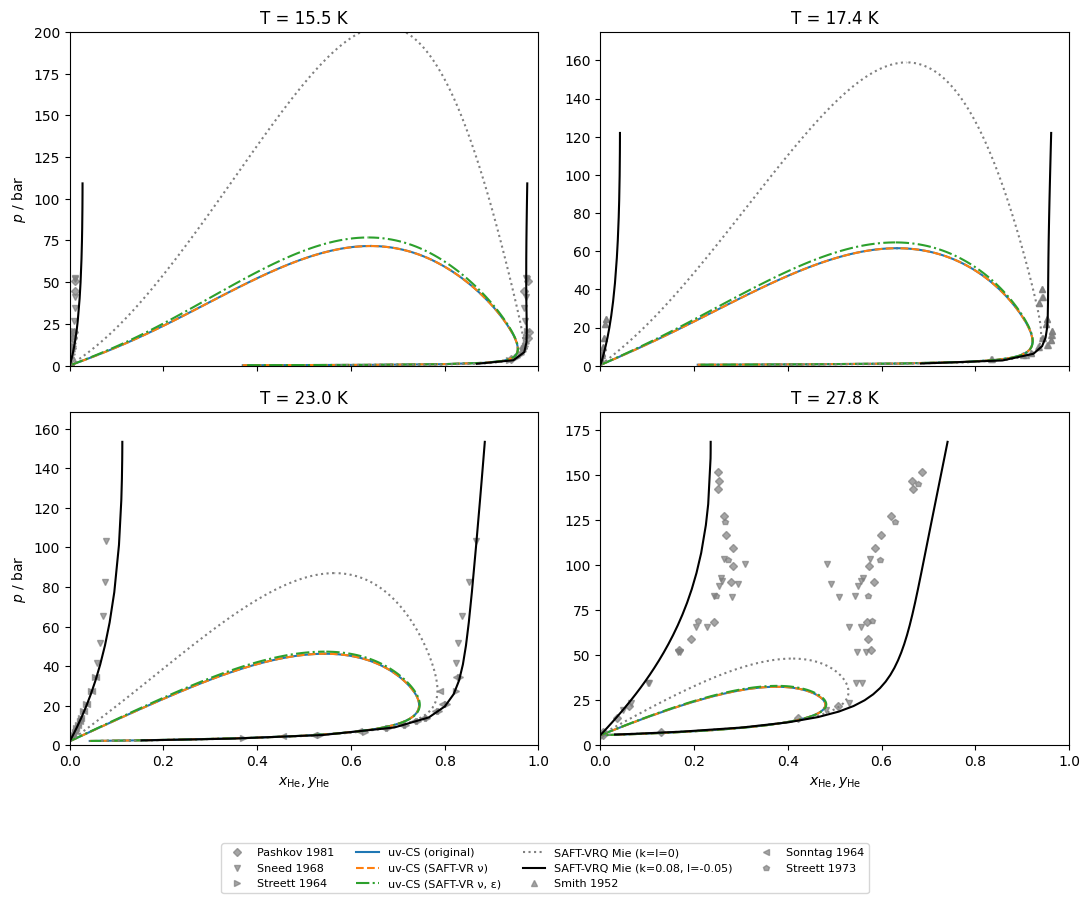

In [12]:
temperatures_exp = [15.5, 17.4, 23.0, 27.8]
curves_exp = {(name, T): bubble_curve(eos, T) for name, eos in models.items() for T in temperatures_exp}
plot_isotherms(temperatures_exp, curves_exp);

### Deviations

For every data point with a liquid composition, a bubble point is computed at $(T, x_\mathrm{He})$. Reported are the absolute average relative deviation of the pressure (AARD$_p$, in %) and the absolute average deviation of the vapor composition (AAD$_y$, only for points with $y_\mathrm{He}$). Points where no bubble point is found (e.g. pressure above the model's mixture critical point) are counted separately as `n_failed` and excluded from the averages.

In [13]:
def deviations(eos, d):
    dp, dy, n_fail = [], [], 0
    for T, p, y, x in d[["T", "p", "y_he", "x_he"]].itertuples(index=False):
        try:
            vle = PhaseEquilibrium.bubble_point(
                eos, T * si.KELVIN, np.array([x, 1 - x]), tp_init=p * si.BAR
            )
            p_calc = vle.vapor.pressure() / si.BAR
            y_calc = vle.vapor.molefracs[0]
            if abs(y_calc - x) < 1e-6:
                raise RuntimeError
        except KeyboardInterrupt:
            raise
        except BaseException:  # also catches Rust panics (PanicException)
            n_fail += 1
            continue
        dp.append(abs(p_calc / p - 1))
        if not np.isnan(y):
            dy.append(abs(y_calc - y))
    return dict(
        AARD_p_percent=100 * np.mean(dp) if dp else np.nan,
        AAD_y=np.mean(dy) if dy else np.nan,
        n_failed=n_fail,
        n=len(d),
    )

#### GEMC data

In [14]:
rows = []
for name, eos in models.items():
    for T in temperatures:
        rows.append(dict(model=name, T=T, **deviations(eos, data[data["T"] == T])))
    rows.append(dict(model=name, T="all", **deviations(eos, data)))
dev = pd.DataFrame(rows)
dev.pivot(index="model", columns="T", values="AARD_p_percent").round(2)

T,20.4,26.0,29.0,31.5,all
model,,,,,
"SAFT-VRQ Mie (k=0.08, l=-0.05)",19.13,23.79,20.20,4.85,18.21
SAFT-VRQ Mie (k=l=0),80.64,52.36,27.88,12.02,44.23
uv-CS (SAFT-VR ν),NaN,63.43,39.97,21.07,45.80
"uv-CS (SAFT-VR ν, ε)",NaN,65.60,39.48,18.57,47.45
uv-CS (original),NaN,63.42,39.96,21.07,45.80


In [15]:
dev.pivot(index="model", columns="T", values="AAD_y").round(4)

T,20.4,26.0,29.0,31.5,all
model,,,,,
"SAFT-VRQ Mie (k=0.08, l=-0.05)",0.0028,0.0397,0.0414,0.0111,0.0270
SAFT-VRQ Mie (k=l=0),0.0656,0.0886,0.0743,0.0557,0.0757
uv-CS (SAFT-VR ν),NaN,0.1505,0.1188,0.0786,0.1230
"uv-CS (SAFT-VR ν, ε)",NaN,0.1340,0.1169,0.0736,0.1159
uv-CS (original),NaN,0.1505,0.1188,0.0786,0.1230


In [16]:
dev.pivot(index="model", columns="T", values="n_failed")

T,20.4,26.0,29.0,31.5,all
model,,,,,
"SAFT-VRQ Mie (k=0.08, l=-0.05)",0,1,0,0,1
SAFT-VRQ Mie (k=l=0),1,0,0,1,2
uv-CS (SAFT-VR ν),5,1,0,0,6
"uv-CS (SAFT-VR ν, ε)",5,1,0,1,7
uv-CS (original),5,1,0,0,6


#### Experimental data (DDB)

Grouped by reference; Py(T) points (no liquid composition) are not used.

In [17]:
exp_x = exp.dropna(subset=["x_he"])
rows = []
for name, eos in models.items():
    for ref, g in exp_x.groupby("reference"):
        rows.append(dict(model=name, reference=ref, **deviations(eos, g)))
    rows.append(dict(model=name, reference="all", **deviations(eos, exp_x)))
dev_exp = pd.DataFrame(rows)
dev_exp.pivot(index="model", columns="reference", values="AARD_p_percent").round(2)

reference,Hiza 1981,Pashkov 1981,Smith 1952,Sneed 1968,Sonntag 1964,Streett 1964,Streett 1973,Yaminishi 1992,all
model,,,,,,,,,
"SAFT-VRQ Mie (k=0.08, l=-0.05)",9.31,45.15,28.39,45.84,9.08,15.54,40.24,7.30,29.94
SAFT-VRQ Mie (k=l=0),47.63,62.53,74.41,50.60,43.70,44.44,56.04,37.46,54.42
uv-CS (SAFT-VR ν),54.60,55.71,72.43,54.01,46.80,42.00,54.86,38.57,50.74
"uv-CS (SAFT-VR ν, ε)",53.89,56.81,72.96,55.26,47.78,43.20,53.92,38.27,51.71
uv-CS (original),54.59,55.71,72.42,54.01,46.79,41.99,54.86,38.56,50.73


In [18]:
dev_exp.pivot(index="model", columns="reference", values="AAD_y").round(4)

reference,Hiza 1981,Pashkov 1981,Smith 1952,Sneed 1968,Sonntag 1964,Streett 1964,Streett 1973,Yaminishi 1992,all
model,,,,,,,,,
"SAFT-VRQ Mie (k=0.08, l=-0.05)",NaN,0.0340,NaN,0.0685,0.0237,0.0165,NaN,0.0308,0.0343
SAFT-VRQ Mie (k=l=0),NaN,0.1227,NaN,0.0428,0.1117,0.1081,NaN,0.2448,0.1028
uv-CS (SAFT-VR ν),NaN,0.1908,NaN,0.0723,0.1803,0.1767,NaN,0.3170,0.1654
"uv-CS (SAFT-VR ν, ε)",NaN,0.1931,NaN,0.0728,0.1775,0.1796,NaN,0.3140,0.1655
uv-CS (original),NaN,0.1907,NaN,0.0723,0.1802,0.1766,NaN,0.3169,0.1654


In [19]:
dev_exp.pivot(index="model", columns="reference", values="n_failed")

reference,Hiza 1981,Pashkov 1981,Smith 1952,Sneed 1968,Sonntag 1964,Streett 1964,Streett 1973,Yaminishi 1992,all
model,,,,,,,,,
"SAFT-VRQ Mie (k=0.08, l=-0.05)",5,23,0,20,5,15,11,0,79
SAFT-VRQ Mie (k=l=0),5,45,0,20,4,13,29,0,116
uv-CS (SAFT-VR ν),8,93,41,42,11,35,38,0,268
"uv-CS (SAFT-VR ν, ε)",7,92,39,40,9,36,38,0,261
uv-CS (original),8,93,41,42,11,35,38,0,268
